In [1]:
# @title Load the imports

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import dataclasses
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import random

In [2]:
# @title Установка seed для воспроизводимости

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [3]:
# @title Структуры данных для экспериментов

@dataclasses.dataclass
class ExperimentSettings:
    """Содержит все параметры, описывающие эксперимент."""
    experiment_name: str
    model_name: str
    learning_rate: float
    batch_size: int
    num_epochs: int
    weight_decay: float
    step_size: int
    gamma: float
    random_seed: int

    def to_dict(self):
        return dataclasses.asdict(self)


@dataclasses.dataclass
class Experiment:
    """Содержит информацию об одном запуске эксперимента."""
    settings: ExperimentSettings
    model: nn.Module
    history: pd.DataFrame
    test_accuracy: float

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        settings_path = os.path.join(path, "settings.json")
        with open(settings_path, "w") as f:
            json.dump(self.settings.to_dict(), f, indent=4)

        model_path = os.path.join(path, "model.pth")
        torch.save(self.model.state_dict(), model_path)

        history_path = os.path.join(path, "history.csv")
        self.history.to_csv(history_path)

        print(f"Experiment saved to {path}")

In [4]:
# @title Загрузка и предобработка данных

def load_and_preprocess_data(settings: ExperimentSettings):
    """Загружает, разделяет и преобразует данные CIFAR-10."""
    set_seed(settings.random_seed)

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

    train_size = int(0.8 * len(full_trainset))
    val_size = len(full_trainset) - train_size
    trainset, valset = random_split(full_trainset, [train_size, val_size], generator=torch.Generator().manual_seed(settings.random_seed))

    trainloader = DataLoader(trainset, batch_size=settings.batch_size, shuffle=True, num_workers=2)
    valloader = DataLoader(valset, batch_size=settings.batch_size, shuffle=False, num_workers=2)
    testloader = DataLoader(testset, batch_size=settings.batch_size, shuffle=False, num_workers=2)

    return trainloader, valloader, testloader

In [5]:
# @title Определение архитектуры модели

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)  # 16x16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)  # 16x16
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)  # 8x8
        self.fc1 = nn.Linear(2048, 256)  # 32 * 8 * 8
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 120)
        self.fc3 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def create_model(settings: ExperimentSettings, device="cpu"):
    """Создает и переносит модель на указанное устройство."""
    set_seed(settings.random_seed)
    model = Net()  # Создаем экземпляр модели
    model.to(device)  # Переносим модель на устройство
    return model

In [6]:
# Функция для вычисления точности
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [7]:
# @title Обучение модели

def train_model(model, trainloader, valloader, settings: ExperimentSettings, device="cpu"):
    """Обучает модель и возвращает историю обучения."""
    set_seed(settings.random_seed)

    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = optim.Adam(model.parameters(
    ), lr=settings.learning_rate, weight_decay=settings.weight_decay)
    scheduler = lr_scheduler.StepLR(
        optimizer, step_size=settings.step_size, gamma=settings.gamma)

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    best_val_accuracy = 0.0
    best_model_state = None  # Сохраняем состояние лучшей модели

    for epoch in range(settings.num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        loop = tqdm(enumerate(trainloader, 0), total=len(
            trainloader), desc=f"Epoch {epoch+1}/{settings.num_epochs}")
        for i, data in loop:
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            accuracy = calculate_accuracy(outputs, labels)
            correct_predictions += accuracy * labels.size(0)
            total_samples += labels.size(0)
            loop.set_postfix(loss=running_loss/(i+1),
                             accuracy=correct_predictions/total_samples)

        scheduler.step()
        epoch_loss = running_loss / len(trainloader)
        epoch_accuracy = correct_predictions / total_samples
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_accuracy)

        # Оценка на валидационном наборе
        model.eval()
        val_loss = 0.0
        val_correct_predictions = 0
        val_total_samples = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_accuracy = calculate_accuracy(outputs, labels)
                val_correct_predictions += accuracy * labels.size(0)
                val_total_samples += labels.size(0)

        val_epoch_loss = val_loss / len(valloader)
        val_epoch_accuracy = val_correct_predictions / val_total_samples
        history["val_loss"].append(val_epoch_loss)
        history["val_accuracy"].append(val_epoch_accuracy)
        print(f"Epoch {epoch+1} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_epoch_accuracy:.4f}, LR: {scheduler.get_last_lr()}")

        # Сохранение лучшей модели
        if val_epoch_accuracy > best_val_accuracy:
            best_val_accuracy = val_epoch_accuracy
            best_model_state = model.state_dict()

    print('Finished Training')
    # Загружаем лучшее состояние модели
    model.load_state_dict(best_model_state)

    return model, pd.DataFrame(history)

In [8]:
# @title Оценка на тестовом наборе

def evaluate_model(model, testloader, device="cpu"):
    """Оценивает модель на тестовом наборе и возвращает точность."""
    model.eval()
    test_correct_predictions = 0
    test_total_samples = 0
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            correct = (predicted == labels).sum().item()
            test_correct_predictions += correct
            test_total_samples += len(labels)

    test_accuracy = test_correct_predictions / test_total_samples
    print(f"Test Accuracy: {test_accuracy:.4f}")
    return test_accuracy

100%|██████████| 170M/170M [00:03<00:00, 45.0MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


Epoch 1/5: 100%|██████████| 625/625 [02:59<00:00,  3.47it/s, accuracy=0.376, loss=1.66]


Epoch 1 - Loss: 1.6551, Accuracy: 0.3756, Val Loss: 1.5390, Val Accuracy: 0.3906, LR: [0.001]


Epoch 2/5: 100%|██████████| 625/625 [02:58<00:00,  3.51it/s, accuracy=0.499, loss=1.38]


...

Epoch 3 - Loss: 1.2436, Accuracy: 0.5515, Val Loss: 1.1254, Val Accuracy: 0.6250, LR: [0.001]


Epoch 4/5: 100%|██████████| 625/625 [03:10<00:00,  3.28it/s, accuracy=0.589, loss=1.15]


Epoch 4 - Loss: 1.1510, Accuracy: 0.5891, Val Loss: 1.0619, Val Accuracy: 0.6875, LR: [0.001]


Epoch 5/5: 100%|██████████| 625/625 [03:17<00:00,  3.16it/s, accuracy=0.62, loss=1.08]


Epoch 5 - Loss: 1.0801, Accuracy: 0.6204, Val Loss: 0.9875, Val Accuracy: 0.5469, LR: [0.001]
Finished Training
Test Accuracy: 0.6878
Experiment saved to ./experiment


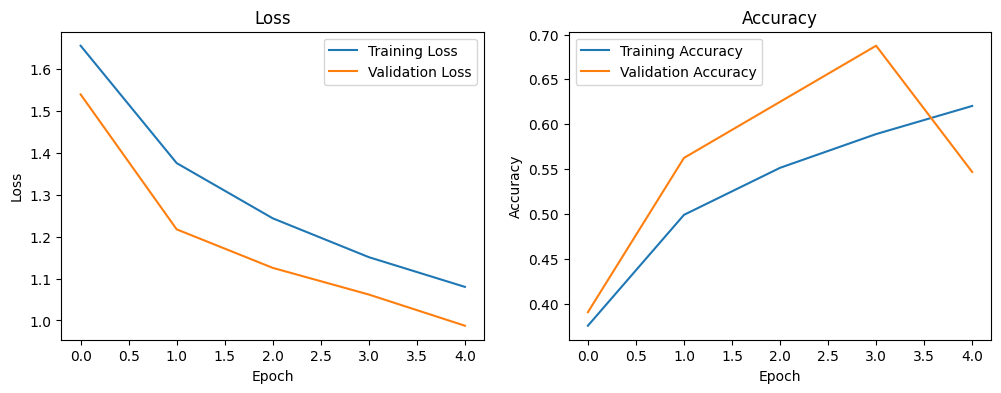

In [11]:
# Определить настройки эксперимента
settings = ExperimentSettings(
    experiment_name="MyFirstExperiment",
    model_name="SimpleCNN",
    learning_rate=0.001, #0.0004281848474430557
    batch_size=64,
    num_epochs=5,
    weight_decay=0.0005, #0.00023075795652605522
    step_size=7, #6
    gamma=0.1, #0.10164841667584665
    random_seed=42
)

# Загрузить и предобработать данные
trainloader, valloader, testloader = load_and_preprocess_data(settings)

# Определить устройство (GPU или CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Создать модель
model = create_model(settings, device)

# Обучить модель
trained_model, history_df = train_model(
    model, trainloader, valloader, settings, device)

# Оценить модель на тестовом наборе
test_accuracy = evaluate_model(trained_model, testloader, device)

# Создать объект Experiment
experiment = Experiment(
    settings=settings,
    model=trained_model,
    history=history_df,
    test_accuracy=test_accuracy
)

# Сохранить эксперимент
experiment.save("./experiment")

# Создаем графики обучения
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# График loss
axs[0].plot(history_df['loss'], label='Training Loss')
axs[0].plot(history_df['val_loss'], label='Validation Loss')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# График accuracy
axs[1].plot(history_df['accuracy'], label='Training Accuracy')
axs[1].plot(history_df['val_accuracy'], label='Validation Accuracy')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()